In [1]:
import xarray as xr
import geopandas as gpd
import rioxarray
import rasterio as rio
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score
import seaborn as sns
from matplotlib.colors import LogNorm

In [ ]:
md_gdf = gpd.read_file(f'../mapping/polygons/imja_md.shp')
moving_gdf = gpd.read_file(f'../mapping/polygons/imja_moving.shp')

In [ ]:
# Imja velocity from this study
stacking_ascending_veloc_ds = xr.open_dataset(f'../dams/imja/imja_asc_median_velocity.tif').squeeze()
stacking_descending_veloc_ds = xr.open_dataset(f'../dams/imja/imja_des_median_velocity.tif').squeeze()
stacking_ud_veloc_ds = xr.open_dataset(f'../dams/imja/imja_ud_median_velocity.tif').squeeze()
stacking_ew_veloc_ds = xr.open_dataset(f'../dams/imja/imja_ew_median_velocity.tif').squeeze()

In [52]:
# Imja velocity from prior study
# stacking_ascending_veloc_ds = xr.open_dataset(f'/mnt/c/Users/qbren/OneDrive - UW/Desktop/taco/projects/imja_fufiters_analysis/mapping/rasters/imja_asc_median_velocity.tif').squeeze()
# stacking_descending_veloc_ds = xr.open_dataset(f'/mnt/c/Users/qbren/OneDrive - UW/Desktop/taco/projects/imja_fufiters_analysis/mapping/rasters/imja_des_median_velocity.tif').squeeze()
ts_ud_veloc_ds = xr.open_dataset(f'/mnt/c/Users/qbren/OneDrive - UW/Desktop/taco/projects/fufiters_imja_analysis/mapping/rasters/vertical_velocity.tif').squeeze()
ts_ew_veloc_ds = xr.open_dataset(f'/mnt/c/Users/qbren/OneDrive - UW/Desktop/taco/projects/fufiters_imja_analysis/mapping/rasters/ew_velocity.tif').squeeze()

In [5]:
dem_ud_veloc_ds = xr.open_dataset(f'/mnt/c/Users/qbren/OneDrive - UW/Desktop/taco/projects/fufiters_imja_analysis/mapping/rasters/dem_vz_resampled.tif').squeeze()
dem_ew_veloc_ds = xr.open_dataset(f'/mnt/c/Users/qbren/OneDrive - UW/Desktop/taco/projects/fufiters_imja_analysis/mapping/rasters/dem_vx_resampled.tif').squeeze()

In [53]:
stacking_ud_veloc_clip_ds = stacking_ud_veloc_ds.rio.clip(md_gdf.geometry, crs=md_gdf.crs)
ts_ud_veloc_clip_ds = ts_ud_veloc_ds.rio.clip(md_gdf.geometry, crs=md_gdf.crs)
dem_ud_veloc_clip_ds = dem_ud_veloc_ds.rio.clip(md_gdf.geometry, crs=md_gdf.crs)

stacking_ew_veloc_clip_ds = stacking_ew_veloc_ds.rio.clip(md_gdf.geometry, crs=md_gdf.crs)
ts_ew_veloc_clip_ds = ts_ew_veloc_ds.rio.clip(md_gdf.geometry, crs=md_gdf.crs)
dem_ew_veloc_clip_ds = dem_ew_veloc_ds.rio.clip(md_gdf.geometry, crs=md_gdf.crs)

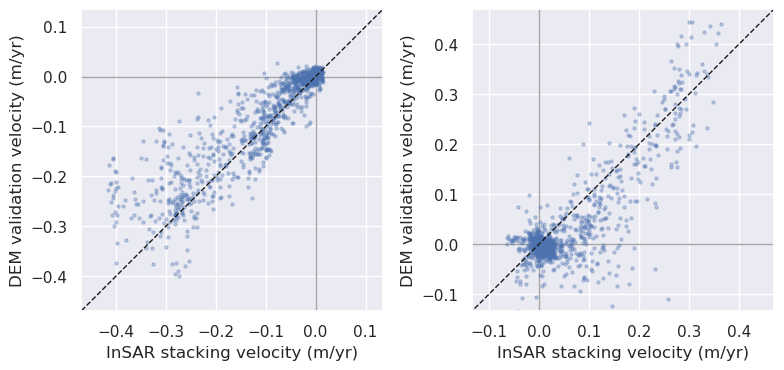

In [57]:
sns.set_theme()
dem_ud_veloc_clip_ds = dem_ud_veloc_clip_ds.rio.reproject_match(stacking_ud_veloc_clip_ds)
dem_ew_veloc_clip_ds = dem_ew_veloc_clip_ds.rio.reproject_match(stacking_ew_veloc_clip_ds)

# Flatten arrays
ud_x = dem_ud_veloc_clip_ds.band_data.values.ravel()
ud_y = stacking_ud_veloc_clip_ds.band_data.values.ravel()
ew_x = dem_ew_veloc_clip_ds.band_data.values.ravel()
ew_y = stacking_ew_veloc_clip_ds.band_data.values.ravel()

# Remove NaNs
mask = np.isfinite(ud_x) & np.isfinite(ud_y)
ud_x, ud_y = ud_x[mask], ud_y[mask]

mask = np.isfinite(ew_x) & np.isfinite(ew_y)
ew_x, ew_y = ew_x[mask], ew_y[mask]

# --- Compute R² relative to 1:1 line ---
ss_res = np.sum((ud_y - ud_x)**2)
ss_tot = np.sum((ud_y - np.mean(ud_y))**2)
ud_r2_1to1 = 1 - ss_res / ss_tot

ss_res = np.sum((ew_y - ew_x)**2)
ss_tot = np.sum((ew_y - np.mean(ew_y))**2)
ew_r2_1to1 = 1 - ss_res / ss_tot

# --- Create plot ---
f, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].axvline(0, c='gray', lw=1, alpha=0.7)
ax[1].axvline(0, c='gray', lw=1, alpha=0.7)
ax[0].axhline(0, c='gray', lw=1, alpha=0.7)
ax[1].axhline(0, c='gray', lw=1, alpha=0.7)

ax[0].scatter(ud_x, ud_y, alpha=0.3, s=5, zorder=2)
ax[1].scatter(ew_x, ew_y, alpha=0.3, s=5, zorder=2)

# sns.histplot(ax=ax[0], x=ud_x, y=ud_y, binwidth=0.03, vmin=None, vmax=None, norm=LogNorm())
# sns.histplot(ax=ax[1], x=ew_x, y=ew_y, binwidth=0.03, vmin=None, vmax=None, norm=LogNorm())

lims = [min(-0.5, np.min([ud_x, ud_y])), max(0.6, np.max([ud_x, ud_y]))]
ax[0].plot(lims, lims, 'k--', lw=1, label='1:1 line')
ax[1].plot(lims, lims, 'k--', lw=1, label='1:1 line')

# Formatting
ax[0].set_xticks([-0.4, -0.3, -0.2, -0.1, 0, 0.1])
ax[1].set_xticks([-0.1, 0, 0.1, 0.2, 0.3, 0.4])
ax[0].set_aspect(1)
ax[1].set_aspect(1)
ax[0].set_xlim(-0.47, 0.135)
ax[0].set_ylim(-0.47, 0.135)
ax[1].set_xlim(-0.135, 0.47)
ax[1].set_ylim(-0.135, 0.47)
ax[0].set_xlabel('InSAR stacking velocity (m/yr)')
ax[0].set_ylabel('DEM validation velocity (m/yr)')
ax[1].set_xlabel('InSAR stacking velocity (m/yr)')
ax[1].set_ylabel('DEM validation velocity (m/yr)')
f.tight_layout()

#ax.legend(loc='best')
plt.savefig('../figs/imja_stacking_validation.png', dpi=400, bbox_inches='tight')

In [58]:
ud_r2_1to1

0.7333566938632918

In [59]:
ew_r2_1to1

0.6453889059800927